### Top and bottom 200 from 80k for WTC11 and NGN2 results

top_bottom_elements_80k_results_wtc11_ngn2.ipynb
This is the notebook used to generate the top and bottom 80k MPRA sequences from the WTC11-NGN2 and undiff WTC11. The first steps were done by MPRAsnakeflow and are not shown within this notebook because the final data from MPRAsnakeflow and the outlier removal as well as the code used to perform BCalm on the data with at least 10 barcodes associated to each Oligo. The WTC11-NGN2 data has 2 additional resequencing runs while we currently wait for the resequencing of the undifferentiated WTC11. So more trust and higher quality of the data for WTC11-NGN2 compared to the undifferentiated WTC11.
To the steps we did within this notebook:
1. We load the data resulting from BCalm for the tested sequences
- In the upper part for WTC11-NGN2 and further down for undifferentiated WTC11
2. We only investigate sequences which are not scrambled and which we have data for
3. We compute the z-score using the mean and sd from a scrambled sequence set
4. We sort the resulting table and take the top 200 and bottom 200 sequences
5. We combine these sequence sets and write it into the respective files 

In [1]:
import ast
import pandas as pd
import os
import numpy as np
import yaml

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [2]:
# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

write_output = False

In [30]:
### Get scrambled in wtc11 and ngn2 and correlate them

### Focus on NGN2 and elements
- Header: NGN2_positive:80k_header

In [3]:
# mpra_80k_metadata_df_bcalm = pd.read_csv(config['files']['creating']["element_metadata_with_bcalm_2025_02_bbmap_scrambled"], sep="\t", low_memory=False)
mpra_80k_metadata_df_bcalm = pd.read_csv(config['files']['creating']["NGN2_element_metadata_with_bcalm_2025_02_bbmap_scrambled"], sep="\t", low_memory=False)

# use safe eval on list
# Apply the safe_eval function to the specified columns
for col in list_columns:
    mpra_80k_metadata_df_bcalm[col] = mpra_80k_metadata_df_bcalm[col].apply(safe_eval)

In [4]:
mpra_80k_metadata_df_bcalm_no_scrambled = mpra_80k_metadata_df_bcalm.loc[~((mpra_80k_metadata_df_bcalm[col_category] == "scrambled") | (~mpra_80k_metadata_df_bcalm["bcalm_data_exists"]))].copy()

mpra_80k_metadata_df_bcalm_no_scrambled[col_start] = mpra_80k_metadata_df_bcalm_no_scrambled[col_start].astype(int)
mpra_80k_metadata_df_bcalm_no_scrambled[col_end] = mpra_80k_metadata_df_bcalm_no_scrambled[col_end].astype(int)

def qc_info(info):
    if not isinstance(info, str):
        return pd.NA
    if "IGVF" in info:
        return pd.NA
    return info

mpra_80k_metadata_df_bcalm_no_scrambled[col_source] = mpra_80k_metadata_df_bcalm_no_scrambled[col_source].apply(qc_info)

In [5]:
# #### Z-score
mpra_80k_metadata_df_bcalm_exists = mpra_80k_metadata_df_bcalm.loc[mpra_80k_metadata_df_bcalm['bcalm_data_exists']].copy()
negative_scrambled_sequences_bcalm = mpra_80k_metadata_df_bcalm_exists.loc[mpra_80k_metadata_df_bcalm_exists[col_name].str.contains("scramb") & (mpra_80k_metadata_df_bcalm_exists.label == "MK")]


mu_ref = negative_scrambled_sequences_bcalm['bcalm_element_log_ratio_activity'].mean()
sigma_ref = np.sqrt(negative_scrambled_sequences_bcalm['bcalm_element_log_ratio_activity'].var())

# # Normalize using mean and variance of 'scrambled'
mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity_z_normalized'] = (mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity'] - mu_ref) / sigma_ref

mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity_not_normlized'] = mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity']
mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity'] = mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity_z_normalized']


In [6]:
# with all sequences:
mpra_80k_metadata_df_bcalm.sort_values(by="bcalm_element_log_ratio_activity", ascending=False, inplace=True)
mpra_80k_metadata_df_bcalm_no_scrambled.sort_values(by="bcalm_element_log_ratio_activity", ascending=False, inplace=True)

# get top
NGN2_80k_top200 = mpra_80k_metadata_df_bcalm.head(200)
NGN2_80k_top200 = mpra_80k_metadata_df_bcalm_no_scrambled.head(200).copy()

In [35]:
NGN2_80k_top200.label.value_counts()
# mpra_80k_metadata_df_bcalm.label.value_counts()

label
MK                           109
C_positive_neuron_NP          37
cardiac_neuro_cava_random     34
C_positive_neuron_MK          18
GC_Cort_Chengyu                1
C_positive_heart_AB            1
Name: count, dtype: int64

In [36]:
print("mean: ", NGN2_80k_top200['bcalm_element_log_ratio_activity'].mean())
print("max: ", NGN2_80k_top200['bcalm_element_log_ratio_activity'].max())
print("min: ", NGN2_80k_top200['bcalm_element_log_ratio_activity'].min())

# without mk:
# mean:  2.1030963693745237
# max:  3.0327824471671
# min:  1.73624120970348

# with MK
# mean:  2.3809859252360583
# max:  4.27578247459959
# min:  2.04207910391479

mean:  6.667424637074168
max:  11.577235193209708
min:  5.789246824565255


In [37]:
NGN2_80k_top200

,name,sequence,category,class,source,ref,chr,start,end,strand,...,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized
1418,MK:rdhs_149005|chr12-49233850+49234119|reference,AGTGCAGGGCAGCATAAACTCTGCAACATAAAAAGAGGGAAGCTGA...,element,element active control,Michael Kosicki,GRCh38,chr12,49233849,49234119,+,...,None,None,None,NaN,2.009550e-57,11.577235,True,MK,11.577235,4.275782
255,MK:newcore_110751|chr13-80276302+80276571|C-G-241,TTCCCAAATGCGTGCATTCTCACCCAGGCTGACTGTTCTTTTCTAC...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80276301,80276571,+,...,[240],None,[alt],NaN,2.912557e-96,11.103977,True,MK,11.103977,4.093143
1613,MK:AC008897.2|chr5-75336921-75337190|reference,GACGAGCCTTCGACCAATAAGAGAGGATCGTTCGATTGTCTAGCCA...,element,element active control,Michael Kosicki,GRCh38,chr5,75336920,75337190,-,...,None,None,None,NaN,2.807794e-37,10.080932,True,MK,10.080932,3.698329
1325,MK:TXNIP|chr1-145996587-145996856|reference,AAGACGCTCAACAGCCCCCTCCTTCCCCTCCTTCCTCTCCTTCCTC...,element,element active control,Michael Kosicki,GRCh38,chr1,145996586,145996856,-,...,None,None,None,NaN,3.108282e-50,10.010189,True,MK,10.010189,3.671027
1640,MK:STMN4|chr8-27258427-27258696|reference,GCAAGCTGTGGCTTCTCCCCAACCTTCTCTGTACCACTCCCTCTTT...,element,element active control,Michael Kosicki,GRCh38,chr8,27258426,27258696,-,...,None,None,None,NaN,2.479370e-59,9.966971,True,MK,9.966971,3.654348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,MK:HSPA4|chr5-133051662+133051931|reference,AGTTTCTTTGATGTTAAGAAAAACGGCGGAAGTAGGCCGCAGCGCT...,element,element active control,Michael Kosicki,GRCh38,chr5,133051661,133051931,+,...,None,None,None,NaN,1.151395e-45,5.795746,True,MK,5.795746,2.044587
79700,C_positive_neuron_MK:tile_34824_chr5_141041068...,ATGGTGTATTATTTAATATCAGTCTGTTGCTCCTCCAGGCTAAAAA...,variant,variant positive control,Michael Kosicki,GRCh38,chr5,141041067,141041337,+,...,[28],[NC_000005.10:141041095:C:G],[alt],NaN,7.930610e-43,5.794508,True,C_positive_neuron_MK,5.794508,2.044109
1711,MK:rdhs_680233|chr8-72316556+72316825|reference,GGTTGGGCTGGGCTGGTTATTTTTCTGTTTGGTCTTAGCTCCCACA...,element,element active control,Michael Kosicki,GRCh38,chr8,72316555,72316825,+,...,None,None,None,NaN,3.991480e-48,5.792126,True,MK,5.792126,2.043190
21254,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,AATGTAGATTTATGACAGTTTTGAAAAATCAGAATGAGTATTGTAG...,variant,test,<NA>,GRCh38,chr16,78129764,78130034,+,...,[212],[NC_000016.10:78129976:T:C],[ref],NaN,1.154173e-153,5.789468,True,cardiac_neuro_cava_random,5.789468,2.042164


In [38]:
# renaming
NGN2_80k_top200['80k_NGN2_top_name'] = "80k_NGN2_positive_control:" + NGN2_80k_top200[col_name]
NGN2_80k_top200.drop(columns=[col_name], inplace=True)
NGN2_80k_top200.rename(columns={'80k_NGN2_top_name': col_name}, inplace=True)


NGN2_80k_top200[col_class] = "element active control"

# add z-score_bcalm_logFC
NGN2_80k_top200[col_info] = f"z-score_scrambled_BCalm_80k_MPRA_NGN2_activity_logFC:" + NGN2_80k_top200["bcalm_element_log_ratio_activity"].round(decimals=3).astype(str)

# finalize
interesting_columns = [col_name, col_sequence, col_category, col_class, col_source,
                       col_ref, col_chr, col_start, col_end, col_strand, col_variant_class, col_variant_pos, col_SPDI, col_allele, col_info]
NGN2_80k_top200[interesting_columns]

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
1418,80k_NGN2_positive_control:MK:rdhs_149005|chr12...,AGTGCAGGGCAGCATAAACTCTGCAACATAAAAAGAGGGAAGCTGA...,element,element active control,Michael Kosicki,GRCh38,chr12,49233849,49234119,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
255,80k_NGN2_positive_control:MK:newcore_110751|ch...,TTCCCAAATGCGTGCATTCTCACCCAGGCTGACTGTTCTTTTCTAC...,variant,element active control,Michael Kosicki,GRCh38,chr13,80276301,80276571,+,[SNV],[240],None,[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
1613,80k_NGN2_positive_control:MK:AC008897.2|chr5-7...,GACGAGCCTTCGACCAATAAGAGAGGATCGTTCGATTGTCTAGCCA...,element,element active control,Michael Kosicki,GRCh38,chr5,75336920,75337190,-,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
1325,80k_NGN2_positive_control:MK:TXNIP|chr1-145996...,AAGACGCTCAACAGCCCCCTCCTTCCCCTCCTTCCTCTCCTTCCTC...,element,element active control,Michael Kosicki,GRCh38,chr1,145996586,145996856,-,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
1640,80k_NGN2_positive_control:MK:STMN4|chr8-272584...,GCAAGCTGTGGCTTCTCCCCAACCTTCTCTGTACCACTCCCTCTTT...,element,element active control,Michael Kosicki,GRCh38,chr8,27258426,27258696,-,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,80k_NGN2_positive_control:MK:HSPA4|chr5-133051...,AGTTTCTTTGATGTTAAGAAAAACGGCGGAAGTAGGCCGCAGCGCT...,element,element active control,Michael Kosicki,GRCh38,chr5,133051661,133051931,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
79700,80k_NGN2_positive_control:C_positive_neuron_MK...,ATGGTGTATTATTTAATATCAGTCTGTTGCTCCTCCAGGCTAAAAA...,variant,element active control,Michael Kosicki,GRCh38,chr5,141041067,141041337,+,[SNV],[28],[NC_000005.10:141041095:C:G],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
1711,80k_NGN2_positive_control:MK:rdhs_680233|chr8-...,GGTTGGGCTGGGCTGGTTATTTTTCTGTTTGGTCTTAGCTCCCACA...,element,element active control,Michael Kosicki,GRCh38,chr8,72316555,72316825,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
21254,80k_NGN2_positive_control:cardiac_neuro_cava_r...,AATGTAGATTTATGACAGTTTTGAAAAATCAGAATGAGTATTGTAG...,variant,element active control,<NA>,GRCh38,chr16,78129764,78130034,+,[SNV],[212],[NC_000016.10:78129976:T:C],[ref],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...


In [39]:
NGN2_80k_top200

,sequence,category,class,source,ref,chr,start,end,strand,variant_class,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,name
1418,AGTGCAGGGCAGCATAAACTCTGCAACATAAAAAGAGGGAAGCTGA...,element,element active control,Michael Kosicki,GRCh38,chr12,49233849,49234119,+,None,...,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,2.009550e-57,11.577235,True,MK,11.577235,4.275782,80k_NGN2_positive_control:MK:rdhs_149005|chr12...
255,TTCCCAAATGCGTGCATTCTCACCCAGGCTGACTGTTCTTTTCTAC...,variant,element active control,Michael Kosicki,GRCh38,chr13,80276301,80276571,+,[SNV],...,None,[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,2.912557e-96,11.103977,True,MK,11.103977,4.093143,80k_NGN2_positive_control:MK:newcore_110751|ch...
1613,GACGAGCCTTCGACCAATAAGAGAGGATCGTTCGATTGTCTAGCCA...,element,element active control,Michael Kosicki,GRCh38,chr5,75336920,75337190,-,None,...,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,2.807794e-37,10.080932,True,MK,10.080932,3.698329,80k_NGN2_positive_control:MK:AC008897.2|chr5-7...
1325,AAGACGCTCAACAGCCCCCTCCTTCCCCTCCTTCCTCTCCTTCCTC...,element,element active control,Michael Kosicki,GRCh38,chr1,145996586,145996856,-,None,...,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,3.108282e-50,10.010189,True,MK,10.010189,3.671027,80k_NGN2_positive_control:MK:TXNIP|chr1-145996...
1640,GCAAGCTGTGGCTTCTCCCCAACCTTCTCTGTACCACTCCCTCTTT...,element,element active control,Michael Kosicki,GRCh38,chr8,27258426,27258696,-,None,...,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,2.479370e-59,9.966971,True,MK,9.966971,3.654348,80k_NGN2_positive_control:MK:STMN4|chr8-272584...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1420,AGTTTCTTTGATGTTAAGAAAAACGGCGGAAGTAGGCCGCAGCGCT...,element,element active control,Michael Kosicki,GRCh38,chr5,133051661,133051931,+,None,...,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,1.151395e-45,5.795746,True,MK,5.795746,2.044587,80k_NGN2_positive_control:MK:HSPA4|chr5-133051...
79700,ATGGTGTATTATTTAATATCAGTCTGTTGCTCCTCCAGGCTAAAAA...,variant,element active control,Michael Kosicki,GRCh38,chr5,141041067,141041337,+,[SNV],...,[NC_000005.10:141041095:C:G],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,7.930610e-43,5.794508,True,C_positive_neuron_MK,5.794508,2.044109,80k_NGN2_positive_control:C_positive_neuron_MK...
1711,GGTTGGGCTGGGCTGGTTATTTTTCTGTTTGGTCTTAGCTCCCACA...,element,element active control,Michael Kosicki,GRCh38,chr8,72316555,72316825,+,None,...,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,3.991480e-48,5.792126,True,MK,5.792126,2.043190,80k_NGN2_positive_control:MK:rdhs_680233|chr8-...
21254,AATGTAGATTTATGACAGTTTTGAAAAATCAGAATGAGTATTGTAG...,variant,element active control,<NA>,GRCh38,chr16,78129764,78130034,+,[SNV],...,[NC_000016.10:78129976:T:C],[ref],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,1.154173e-153,5.789468,True,cardiac_neuro_cava_random,5.789468,2.042164,80k_NGN2_positive_control:cardiac_neuro_cava_r...


#### Bottom:

In [40]:
NGN2_80k_bottom200 = mpra_80k_metadata_df_bcalm_no_scrambled.tail(200).copy()
NGN2_80k_bottom200

NGN2_80k_bottom200.label.value_counts()


label
cardiac_neuro_cava_random    167
C_negative_neuron_NP          19
C_negative_neuron_MK           6
GC_Selvarajan                  3
C_negative_heart_MK            2
C_positive_heart_CAD           2
C_positive_heart_AB            1
Name: count, dtype: int64

In [41]:
print("mean: ", NGN2_80k_bottom200['bcalm_element_log_ratio_activity'].mean())
print("max: ", NGN2_80k_bottom200['bcalm_element_log_ratio_activity'].max())
print("min: ", NGN2_80k_bottom200['bcalm_element_log_ratio_activity'].min())

# mean:  -3.8990881998456235
# max:  -3.525755996540471
# min:  -5.293136071750182

mean:  -3.896849346093197
max:  -3.5257458467484795
min:  -5.293136071750182


In [42]:
# renaming
NGN2_80k_bottom200['80k_NGN2_bottom_name'] = "80k_NGN2_negative_control:" + NGN2_80k_bottom200[col_name]
NGN2_80k_bottom200.drop(columns=[col_name], inplace=True)
NGN2_80k_bottom200.rename(columns={'80k_NGN2_bottom_name': col_name}, inplace=True)

NGN2_80k_bottom200[col_class] = "element inactive control"

# add z-score_bcalm_logFC
NGN2_80k_bottom200[col_info] = f"z-score_scrambled_BCalm_80k_MPRA_NGN2_activity_logFC:" + NGN2_80k_bottom200["bcalm_element_log_ratio_activity"].round(decimals=3).astype(str)

# finalize
interesting_columns = [col_name, col_sequence, col_category, col_class, col_source,
                       col_ref, col_chr, col_start, col_end, col_strand, col_variant_class, col_variant_pos, col_SPDI, col_allele, col_info]
NGN2_80k_bottom200[interesting_columns]


,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
3833,80k_NGN2_negative_control:C_negative_heart_MK:...,GCATGACTTCAGAGGCCTGTCAAGAGGGCAGGTAATTCACCTTTGC...,element,element inactive control,<NA>,GRCh38,chr11,8914675,8914945,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
15935,80k_NGN2_negative_control:cardiac_neuro_cava_r...,CAGAGAGGTTTCCAGGATCCTGTCACAGGGTCCATAAGATGTAAAG...,variant,element inactive control,<NA>,GRCh38,chr1,224127114,224127384,+,"[SNV, SNV, SNV, SNV, SNV]","[69, 184, 197, 198, 212]","[NC_000001.11:224127183:A:G, NC_000001.11:2241...","[ref, ref, ref, ref, ref]",z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
65268,80k_NGN2_negative_control:cardiac_neuro_cava_r...,AAAGGTGGTGGGGGGTGTAAAAGTACTTGCTTCAAGTTCAGTGTGT...,variant,element inactive control,<NA>,GRCh38,chr3,142597108,142597378,-,[SNV],[200],[NC_000003.12:142597177:C:T],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
35387,80k_NGN2_negative_control:cardiac_neuro_cava_r...,GGGCCTCAGTGTTAACCTTCCCAGGTTCAGATCCCAGCTTTACCCC...,variant,element inactive control,<NA>,GRCh38,chr1,94856161,94856431,-,[SNV],[152],[NC_000001.11:94856278:C:T],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
37660,80k_NGN2_negative_control:cardiac_neuro_cava_r...,TCAGGCACCAGACTAAACTTCCTGATTTACCAGAAATCCTCTAAAT...,variant,element inactive control,<NA>,GRCh38,chr1,231027511,231027781,+,[SNV],[234],[NC_000001.11:231027745:T:C],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6528,80k_NGN2_negative_control:cardiac_neuro_cava_r...,AACACTGATGCTGCAGTCAGCAGACACCTCACCTGCATTGCTGTGT...,element,element inactive control,<NA>,GRCh38,chr3,46584816,46585086,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
18618,80k_NGN2_negative_control:cardiac_neuro_cava_r...,AGCCTGGGCGACAGAGCAAGACTCTCTCTCAAAAACAAAACAAAAC...,variant,element inactive control,<NA>,GRCh38,chr12,111263594,111263864,+,[SNV],[138],[NC_000012.12:111263732:G:A],[ref],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
69080,80k_NGN2_negative_control:cardiac_neuro_cava_r...,TCCAAGTATTGTGTCTGGAATTTGAGTTCCTGCTCTCACTGACTTC...,variant,element inactive control,<NA>,GRCh38,chr6,425166,425436,+,[SNV],[155],[NC_000006.12:425321:G:C],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...
62577,80k_NGN2_negative_control:cardiac_neuro_cava_r...,TGAAATGGAGCATCGCCAGAGAGCCTGGAAGAAATGCAGTCTCAGG...,variant,element inactive control,<NA>,GRCh38,chr3,8712599,8712869,+,[SNV],[151],[NC_000003.12:8712750:G:A],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...


In [43]:
NGN2_80k_bottom200

,sequence,category,class,source,ref,chr,start,end,strand,variant_class,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,name
3833,GCATGACTTCAGAGGCCTGTCAAGAGGGCAGGTAATTCACCTTTGC...,element,element inactive control,<NA>,GRCh38,chr11,8914675,8914945,+,None,...,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,7.771100e-06,-3.525746,True,C_negative_heart_MK,-3.525746,-1.552768,80k_NGN2_negative_control:C_negative_heart_MK:...
15935,CAGAGAGGTTTCCAGGATCCTGTCACAGGGTCCATAAGATGTAAAG...,variant,element inactive control,<NA>,GRCh38,chr1,224127114,224127384,+,"[SNV, SNV, SNV, SNV, SNV]",...,"[NC_000001.11:224127183:A:G, NC_000001.11:2241...","[ref, ref, ref, ref, ref]",z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,7.295620e-15,-3.525756,True,cardiac_neuro_cava_random,-3.525756,-1.552771,80k_NGN2_negative_control:cardiac_neuro_cava_r...
65268,AAAGGTGGTGGGGGGTGTAAAAGTACTTGCTTCAAGTTCAGTGTGT...,variant,element inactive control,<NA>,GRCh38,chr3,142597108,142597378,-,[SNV],...,[NC_000003.12:142597177:C:T],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,9.792305e-09,-3.526925,True,cardiac_neuro_cava_random,-3.526925,-1.553222,80k_NGN2_negative_control:cardiac_neuro_cava_r...
35387,GGGCCTCAGTGTTAACCTTCCCAGGTTCAGATCCCAGCTTTACCCC...,variant,element inactive control,<NA>,GRCh38,chr1,94856161,94856431,-,[SNV],...,[NC_000001.11:94856278:C:T],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,1.842657e-13,-3.531115,True,cardiac_neuro_cava_random,-3.531115,-1.554840,80k_NGN2_negative_control:cardiac_neuro_cava_r...
37660,TCAGGCACCAGACTAAACTTCCTGATTTACCAGAAATCCTCTAAAT...,variant,element inactive control,<NA>,GRCh38,chr1,231027511,231027781,+,[SNV],...,[NC_000001.11:231027745:T:C],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,8.593709e-06,-3.531883,True,cardiac_neuro_cava_random,-3.531883,-1.555136,80k_NGN2_negative_control:cardiac_neuro_cava_r...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6528,AACACTGATGCTGCAGTCAGCAGACACCTCACCTGCATTGCTGTGT...,element,element inactive control,<NA>,GRCh38,chr3,46584816,46585086,+,None,...,None,None,z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,2.407800e-11,-4.797462,True,cardiac_neuro_cava_random,-4.797462,-2.043549,80k_NGN2_negative_control:cardiac_neuro_cava_r...
18618,AGCCTGGGCGACAGAGCAAGACTCTCTCTCAAAAACAAAACAAAAC...,variant,element inactive control,<NA>,GRCh38,chr12,111263594,111263864,+,[SNV],...,[NC_000012.12:111263732:G:A],[ref],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,8.366452e-14,-4.883640,True,cardiac_neuro_cava_random,-4.883640,-2.076807,80k_NGN2_negative_control:cardiac_neuro_cava_r...
69080,TCCAAGTATTGTGTCTGGAATTTGAGTTCCTGCTCTCACTGACTTC...,variant,element inactive control,<NA>,GRCh38,chr6,425166,425436,+,[SNV],...,[NC_000006.12:425321:G:C],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,6.799510e-15,-4.893082,True,cardiac_neuro_cava_random,-4.893082,-2.080451,80k_NGN2_negative_control:cardiac_neuro_cava_r...
62577,TGAAATGGAGCATCGCCAGAGAGCCTGGAAGAAATGCAGTCTCAGG...,variant,element inactive control,<NA>,GRCh38,chr3,8712599,8712869,+,[SNV],...,[NC_000003.12:8712750:G:A],[alt],z-score_scrambled_BCalm_80k_MPRA_NGN2_activity...,3.838831e-11,-5.209719,True,cardiac_neuro_cava_random,-5.209719,-2.202647,80k_NGN2_negative_control:cardiac_neuro_cava_r...


In [44]:
# concat ngn2 top and bottom results:
ngn2_80k_controls = pd.concat([NGN2_80k_top200[interesting_columns], NGN2_80k_bottom200[interesting_columns]], ignore_index=True)

In [74]:
# ngn2_80k_controls.to_csv("/home/kisa/coding/80K_MPRA/collaborations/ahituv_top_bottom_WTC11_NGN2/tested_80k_NGN2_positive_negative_controls.tsv.gz", sep="\t", index=False)

ngn2_80k_controls[interesting_columns].to_csv("/home/kisa/coding/80K_MPRA/collaborations/ahituv_top_bottom_WTC11_NGN2/tested_80k_NGN2_positive_negative_controls.tmp.tsv.gz", sep='\t', index=False, na_rep='NA', compression='gzip')
os.system(f'zcat /home/kisa/coding/80K_MPRA/collaborations/ahituv_top_bottom_WTC11_NGN2/tested_80k_NGN2_positive_negative_controls.tmp.tsv.gz | sed "s/\'/\\"/g" | gzip -c > /home/kisa/coding/80K_MPRA/collaborations/ahituv_top_bottom_WTC11_NGN2/tested_80k_NGN2_positive_negative_controls.tsv.gz')

0

### Focus on undifferenciated WTC11

In [7]:
wtc11_mpra_80k_metadata_df_bcalm = pd.read_csv(config['files']['creating']["WTC11_element_metadata_with_bcalm_2025_02_bbmap_scrambled"], sep="\t", low_memory=False)

# use safe eval on list
# Apply the safe_eval function to the specified columns
for col in list_columns:
    wtc11_mpra_80k_metadata_df_bcalm[col] = wtc11_mpra_80k_metadata_df_bcalm[col].apply(safe_eval)

In [8]:
wtc11_mpra_80k_metadata_df_bcalm_no_scrambled = wtc11_mpra_80k_metadata_df_bcalm.loc[~(wtc11_mpra_80k_metadata_df_bcalm[col_name].str.startswith("MK:") | (wtc11_mpra_80k_metadata_df_bcalm[col_category] == "scrambled") | (~wtc11_mpra_80k_metadata_df_bcalm["bcalm_data_exists"]))].copy()

wtc11_mpra_80k_metadata_df_bcalm_no_scrambled[col_start] = wtc11_mpra_80k_metadata_df_bcalm_no_scrambled[col_start].astype(int)
wtc11_mpra_80k_metadata_df_bcalm_no_scrambled[col_end] = wtc11_mpra_80k_metadata_df_bcalm_no_scrambled[col_end].astype(int)

def qc_info(info):
    if not isinstance(info, str):
        return pd.NA
    if "IGVF" in info:
        return pd.NA
    return info

wtc11_mpra_80k_metadata_df_bcalm_no_scrambled[col_source] = wtc11_mpra_80k_metadata_df_bcalm_no_scrambled[col_source].apply(qc_info)

In [9]:
# #### Z-score
wtc11_mpra_80k_metadata_df_bcalm_exists = wtc11_mpra_80k_metadata_df_bcalm.loc[wtc11_mpra_80k_metadata_df_bcalm['bcalm_data_exists']].copy()
wtc11_negative_scrambled_sequences_bcalm = wtc11_mpra_80k_metadata_df_bcalm_exists.loc[wtc11_mpra_80k_metadata_df_bcalm_exists[col_name].str.contains("scramb") & (wtc11_mpra_80k_metadata_df_bcalm_exists.label == "MK")]


mu_ref = wtc11_negative_scrambled_sequences_bcalm['bcalm_element_log_ratio_activity'].mean()
sigma_ref = np.sqrt(wtc11_negative_scrambled_sequences_bcalm['bcalm_element_log_ratio_activity'].var())

# # Normalize using mean and variance of 'scrambled'
wtc11_mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity_z_normalized'] = (wtc11_mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity'] - mu_ref) / sigma_ref

wtc11_mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity_not_normlized'] = wtc11_mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity']
wtc11_mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity'] = wtc11_mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_log_ratio_activity_z_normalized']


In [10]:
# with all sequences:
wtc11_mpra_80k_metadata_df_bcalm_no_scrambled.sort_values(by="bcalm_element_log_ratio_activity", ascending=False, inplace=True)

# get top
wtc11_80k_top200 = wtc11_mpra_80k_metadata_df_bcalm_no_scrambled.head(200).copy()

In [50]:
print("mean: ", wtc11_80k_top200['bcalm_element_log_ratio_activity'].mean())
print("max: ", wtc11_80k_top200['bcalm_element_log_ratio_activity'].max())
print("min: ", wtc11_80k_top200['bcalm_element_log_ratio_activity'].min())

# mean:  1.176299811564327
# max:  3.79153519185495
# min:  0.828189364328773

mean:  3.939783747425905
max:  12.663719037020096
min:  2.778552510573646


In [51]:
# renaming
wtc11_80k_top200['80k_WTC11_top_name'] = "80k_WTC11_positive_control:" + wtc11_80k_top200[col_name]
wtc11_80k_top200.drop(columns=[col_name], inplace=True)
wtc11_80k_top200.rename(columns={'80k_WTC11_top_name': col_name}, inplace=True)

wtc11_80k_top200[col_class] = "element active control"

# add z-score_bcalm_logFC
wtc11_80k_top200[col_info] = f"z-score_scrambled_BCalm_80k_MPRA_WTC11_activity_logFC:" + wtc11_80k_top200["bcalm_element_log_ratio_activity"].round(decimals=3).astype(str)


# finalize
interesting_columns = [col_name, col_sequence, col_category, col_class, col_source,
                       col_ref, col_chr, col_start, col_end, col_strand, col_variant_class, col_variant_pos, col_SPDI, col_allele, col_info]
wtc11_80k_top200[interesting_columns]

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
79549,80k_WTC11_positive_control:C_positive_neuron_N...,CCCTGGAACTCCCCGCGCGTGTTGTGACCCAGAATTCCCGGGGCTG...,element,element active control,Nick Page,GRCh38,chr17,16438826,16439096,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
79541,80k_WTC11_positive_control:C_positive_neuron_N...,TGATAGCAAACGCCATCTTTCTGCGGAGCCCGCCTGAGCTGCGGCA...,element,element active control,Nick Page,GRCh38,chrX,71182002,71182272,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
80175,80k_WTC11_positive_control:GC_GABA_Chengyu:GAB...,GAGTGTACGAATAGGGTGTGGGTCACAGAGATCACATGCTTTAAGG...,element,element active control,<NA>,GRCh38,chr12,29884984,29885254,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
80124,80k_WTC11_positive_control:GC_GABA_Chengyu:GAB...,CATCTGTGAGCCTGTGTGTGTGTATATGCAAACCTCTGATCTGTGT...,element,element active control,<NA>,GRCh38,chr2,68908454,68908724,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
70711,80k_WTC11_positive_control:cardiac_neuro_cava_...,TTAAATACAAAGCAATTTCACTAATAAAATGCTCAAGCAGTCTAGA...,variant,element active control,<NA>,GRCh38,chr6,71478861,71479131,+,[SNV],[141],[NC_000006.12:71479002:A:T],[alt],z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32039,80k_WTC11_positive_control:cardiac_neuro_cava_...,TTTAACTTACTTTCAACCAATTTATATGTTAAAGCTATTTATATCT...,variant,element active control,<NA>,GRCh38,chrX,33322506,33322776,-,"[SNV, SNV]","[219, 55]","[NC_000023.11:33322556:G:C, NC_000023.11:33322...","[ref, ref]",z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
56910,80k_WTC11_positive_control:cardiac_neuro_cava_...,GCCTCAAAAAGCCAATCGTAGGTTCTACTATAGAGATGCTCTCTGC...,variant,element active control,<NA>,GRCh38,chr2,2007771,2008041,-,[SNV],[227],[NC_000002.12:2007813:C:T],[alt],z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
29565,80k_WTC11_positive_control:cardiac_neuro_cava_...,GATTTTTTTTTCTTTCCTTCTATTCTCAGCAACAATAAGTACTCTT...,variant,element active control,<NA>,GRCh38,chr7,69953369,69953639,+,"[SNV, SNV, SNV, SNV]","[61, 97, 159, 198]","[NC_000007.14:69953430:A:G, NC_000007.14:69953...","[ref, ref, ref, ref]",z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
71372,80k_WTC11_positive_control:cardiac_neuro_cava_...,GAGAGAGAGAATTAAGTGCTGGCTGTTTTATTATGGGCAAGAAAAA...,variant,element active control,<NA>,GRCh38,chr6,142935925,142936195,-,[SNV],[146],[NC_000006.12:142936048:T:G],[alt],z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...


#### Bottom: Undifferentiated

In [52]:
# get top
wtc11_80k_bottom200 = wtc11_mpra_80k_metadata_df_bcalm_no_scrambled.tail(200).copy()

print("mean: ", wtc11_80k_bottom200['bcalm_element_log_ratio_activity'].mean())
print("max: ", wtc11_80k_bottom200['bcalm_element_log_ratio_activity'].max())
print("min: ", wtc11_80k_bottom200['bcalm_element_log_ratio_activity'].min())

# mean:  -1.112019473160098
# max:  -0.960427032492485
# min:  -1.8028891791637

# renaming
wtc11_80k_bottom200['80k_WTC11_top_name'] = "80k_WTC11_negative_control:" + wtc11_80k_bottom200[col_name]
wtc11_80k_bottom200.drop(columns=[col_name], inplace=True)
wtc11_80k_bottom200.rename(columns={'80k_WTC11_top_name': col_name}, inplace=True)

# change class
wtc11_80k_bottom200[col_class] = "element inactive control"

# add z-score_bcalm_logFC
wtc11_80k_bottom200[col_info] = f"z-score_scrambled_BCalm_80k_MPRA_WTC11_activity_logFC:" + wtc11_80k_bottom200["bcalm_element_log_ratio_activity"].round(decimals=3).astype(str)


# finalize
interesting_columns = [col_name, col_sequence, col_category, col_class, col_source,
                       col_ref, col_chr, col_start, col_end, col_strand, col_variant_class, col_variant_pos, col_SPDI, col_allele, col_info]
wtc11_80k_bottom200[interesting_columns]

mean:  -3.693620691928197
max:  -3.187936709238676
min:  -5.9982326033985185


,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
48269,80k_WTC11_negative_control:cardiac_neuro_cava_...,GAAGCTCAGTGACGCTCTTGGCCTTCTGCCTCTTCCATTCCCCGGC...,variant,element inactive control,<NA>,GRCh38,chr15,67186300,67186570,+,[SNV],[161],[NC_000015.10:67186461:G:C],[alt],z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
72988,80k_WTC11_negative_control:cardiac_neuro_cava_...,GGGCAACAGAGTGAGATCCTATCTCAAAAACAAACAAAGAAAAAAG...,variant,element inactive control,<NA>,GRCh38,chr7,101882159,101882429,+,[SNV],[38],[NC_000007.14:101882197:C:G],[alt],z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
18756,80k_WTC11_negative_control:cardiac_neuro_cava_...,ATCTGTCTCTGAAATAACAAAAGTGAAGCTTTGTGGTAAGAAACTA...,variant,element inactive control,<NA>,GRCh38,chr12,116164008,116164278,-,"[SNV, SNV]","[221, 74]","[NC_000012.12:116164056:C:A, NC_000012.12:1161...","[ref, ref]",z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
46795,80k_WTC11_negative_control:cardiac_neuro_cava_...,TATTTAAGATGTGCTCATTTCTTTCTGAATTTGTATTTCTCATCAC...,variant,element inactive control,<NA>,GRCh38,chr15,25343156,25343426,-,[SNV],[116],[NC_000015.10:25343309:A:G],[alt],z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
73945,80k_WTC11_negative_control:cardiac_neuro_cava_...,TGAGCTGGGACAGTGCACCAGGCCCCATGGGATAGCGATAAGCGAG...,variant,element inactive control,<NA>,GRCh38,chr7,151690670,151690940,-,[SNV],[62],[NC_000007.14:151690877:C:T],[alt],z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58064,80k_WTC11_negative_control:cardiac_neuro_cava_...,TCATTTGGTTCTTAGAAGAACTACAACTGTACTTTGAAGAAGTATG...,variant,element inactive control,<NA>,GRCh38,chr2,157725899,157726169,-,[SNV],[181],[NC_000002.12:157725987:C:A],[alt],z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
15815,80k_WTC11_negative_control:cardiac_neuro_cava_...,GAGAGAGAGAGAGTATGTGTGTGTAGGGGAGGTCGTTAGGCAACTG...,variant,element inactive control,<NA>,GRCh38,chr1,201311431,201311701,-,"[SNV, SNV, SNV, SNV, SNV]","[208, 180, 169, 166, 33]","[NC_000001.11:201311492:G:A, NC_000001.11:2013...","[ref, ref, ref, ref, ref]",z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
62716,80k_WTC11_negative_control:cardiac_neuro_cava_...,GTCTCTGAGGCACACCCGTCTTGTGGATGTGTAGACAGAAAACACG...,variant,element inactive control,<NA>,GRCh38,chr3,10957056,10957326,+,[SNV],[47],[NC_000003.12:10957103:G:A],[alt],z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...
79889,80k_WTC11_negative_control:C_negative_neuron_N...,TTTCCATAGCCAGTGAGGCTTATATAATCCCCTTTATCTCCATTCT...,element,element inactive control,Nick Page,GRCh38,chr4,112626408,112626678,+,None,None,None,None,z-score_scrambled_BCalm_80k_MPRA_WTC11_activit...


In [53]:
wtc11_80k_controls = pd.concat([wtc11_80k_top200[interesting_columns], wtc11_80k_bottom200[interesting_columns]], ignore_index=True)

In [54]:
wtc11_80k_controls.to_csv("/home/kisa/coding/80K_MPRA/collaborations/ahituv_top_bottom_WTC11_NGN2/tested_80k_undiff_WTC11_positive_negative_controls.tsv.gz", sep="\t", index=False)

In [73]:
wtc11_80k_controls[interesting_columns].to_csv("/home/kisa/coding/80K_MPRA/collaborations/ahituv_top_bottom_WTC11_NGN2/tested_80k_undiff_WTC11_positive_negative_controls.tmp.tsv.gz", sep='\t', index=False, na_rep='NA', compression='gzip')
os.system(f'zcat /home/kisa/coding/80K_MPRA/collaborations/ahituv_top_bottom_WTC11_NGN2/tested_80k_undiff_WTC11_positive_negative_controls.tmp.tsv.gz | sed "s/\'/\\"/g" | gzip -c > /home/kisa/coding/80K_MPRA/collaborations/ahituv_top_bottom_WTC11_NGN2/tested_80k_undiff_WTC11_positive_negative_controls.tsv.gz')

0

In [28]:
asdfasdfsdf

NameError: name 'asdfasdfsdf' is not defined

In [61]:
ngn2_80k_controls['label'] = ngn2_80k_controls['name'].apply(lambda name: name.split(":")[1])

In [ ]:
ngn2_80k_controls.label.value_counts()
ngn2_80k_controls['name'].nunique()

400

#### Overlap of top and bottom controls

In [64]:
wtc11_top = set(wtc11_80k_top200[col_name].to_list())
ngn2_top = set(NGN2_80k_top200[col_name].to_list())
wtc11_bottom = set(wtc11_80k_bottom200[col_name].to_list())
ngn2_bottom = set(NGN2_80k_bottom200[col_name].to_list())


In [65]:
wtc11_top.intersection(ngn2_top)

set()

In [66]:
wtc11_bottom.intersection(ngn2_bottom)

set()

In [67]:
ngn2_top.intersection(wtc11_bottom)


set()

In [68]:
ngn2_bottom.intersection(wtc11_top)

set()

In [ ]:
wtc11_80k_top200[interesting_columns]

wtc11_80k_bottom200[interesting_columns]

In [ ]:
NGN2_80k_top200[interesting_columns]

NGN2_80k_bottom200[interesting_columns]

#### Corrleation of scrambled between wtc11 and ngn2 

In [ ]:
negative_scrambled_sequences_bcalm.rename(columns={'name': 'NGN2_name', 'bcalm_element_log_ratio_activity': 'NGN2_bcalm_element_log_ratio_activity'})

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label
79605,MK:tile_45190|chr9-22081705+22081974|scramble_...,GGACAACACTGGTGCCTCTTTGCTTCTTAACCTCAGGTATAATGTG...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,8.876937e-26,0.822082,True,MK
79763,MK:tile_15984|chr16-52707150+52707419|scramble...,TCGCAGTTCTCCATCAACTTCTATTTGCTAGTCTCTGGGATTTGTG...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,1.629113e-07,0.555235,True,MK
79679,MK:tile_26461|chr21-34445847+34446116|scramble...,TGGCCTTCTGCGTCTGACGTCACGCCGCAGGTTCCCAGCAGGCACA...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,4.688427e-01,0.519345,True,MK
79803,MK:tile_11141|chr13-105128123+105128392|scramb...,GTGCATGTCTTTTGTCTTTGTTTCAAGAAAGGGCGCTGTTTACCAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,2.579578e-02,0.429361,True,MK
79971,MK:tile_4200|chr1-237030777+237031046|scramble...,TGTTCTAGGGGGGCGCCAATCAATCAAGTTTGAACATAATGGGTAA...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,7.035295e-01,0.420852,True,MK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79788,MK:tile_19379|chr18-47412513+47412782|scramble...,GACAGGCCCCTTTCCTTGGAATTTTCAATGCTCGCTCAAGTGTCTA...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,8.232616e-05,-1.368057,True,MK
79686,MK:tile_3197|chr1-201354239+201354508|scramble...,AGAAATCACCCACGTCCTCAATAGACGGTGTACACCTGCTTCCATG...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,2.768111e-06,-1.642792,True,MK
79869,MK:tile_46909|chr9-129863470+129863739|scrambl...,TCTTTGCAACTTTATCGCGGCTAACAGTTGAACCAATCGCGTAAGA...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,8.681069e-09,-1.656138,True,MK
80035,MK:tile_14356|chr15-67031618+67031887|scramble...,TGAAGCCCCTGATTCTGTTAGAATAAGGTTACTGAGTCGTGTATAC...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,8.333151e-11,-1.821742,True,MK


In [ ]:
wtc11_negative_scrambled_sequences_bcalm

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label
79537,MK:tile_35551|chr5-173255689+173255958|scrambl...,CATGCCTTCTATAGTTTTCGTTTGTCGGGTTAAATAAGGCGGGACC...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,0.999945,-0.390658,True,MK
79539,MK:tile_45208|chr9-22087668+22087937|scramble_...,GTAAAATGAAGCTGTTGATACTATTGTCTGAAACCAATCAACCTAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,0.999945,0.173289,True,MK
79540,MK:tile_23759|chr2-197868362+197868631|scrambl...,TGCTATTTATGAAATTAGTTGGCTTACAATCCCATTACTTTACGCT...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,0.999945,0.195843,True,MK
79541,MK:tile_20126|chr19-10889768+10890037|scramble...,TGAATCAAGAAAGCTGCTCCATGACACCTTCTGTGGTTTTCTCCAA...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,0.999945,-0.388583,True,MK
79542,MK:tile_33101|chr5-33059101+33059370|scramble_...,AATGAATCAAAGCGTCAAACTAAGTGGGCTGAAAAGAATGCTTGCT...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,0.999945,0.211834,True,MK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80018,MK:tile_45374|chr9-30937824+30938093|scramble_...,AGAAATCAGTGGTAAGAACTCTGTGTAAAATAAAATTTAATGGGCC...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,0.999945,0.390992,True,MK
80025,MK:tile_19580|chr18-55369078+55369347|scramble...,AATGTTCTATACTGTCTATGTGACTGTCTTACTATAGTATAACCAC...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,0.999945,-0.186798,True,MK
80027,MK:tile_4359|chr10-3089500+3089769|scramble_ne...,TGATTAATTTTATACAATTAAATAGTTCATGTTGATAAATCATAAA...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,0.999945,0.018460,True,MK
80032,MK:tile_2240|chr1-116244322+116244591|scramble...,CTTAATCAAATAACCCATTAATTCTATATATCTACCTAATATTAAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,NaN,NaN,NaN,NaN,None,None,None,None,NaN,0.999945,0.138407,True,MK


Text(0.5, 1.0, 'WTC11 and NGN2 scrambled sequences correlation: rho: 0.54; pearson: 0.61')

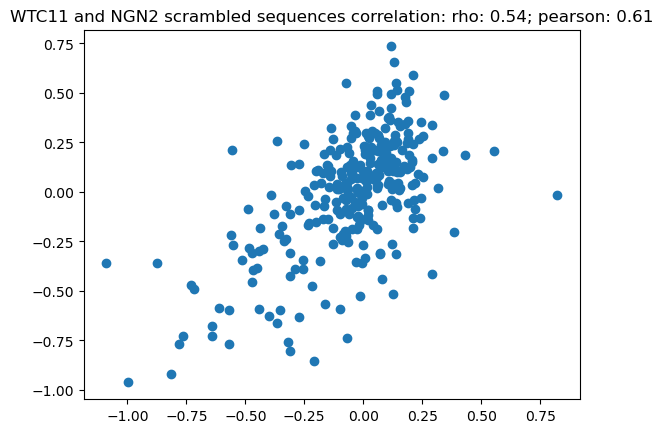

In [ ]:
wtc11_ngn2_correlation_scrambled_spear =  wtc11_negative_scrambled_sequences_bcalm.merge(negative_scrambled_sequences_bcalm.rename(columns={'bcalm_element_log_ratio_activity': 'NGN2_bcalm_element_log_ratio_activity'})[['name', 'NGN2_bcalm_element_log_ratio_activity']], on='name' , how="inner")[['bcalm_element_log_ratio_activity', 'NGN2_bcalm_element_log_ratio_activity']].corr(method="spearman").iloc[0, 1]
wtc11_ngn2_correlation_scrambled_pearson =  wtc11_negative_scrambled_sequences_bcalm.merge(negative_scrambled_sequences_bcalm.rename(columns={'bcalm_element_log_ratio_activity': 'NGN2_bcalm_element_log_ratio_activity'})[['name', 'NGN2_bcalm_element_log_ratio_activity']], on='name' , how="inner")[['bcalm_element_log_ratio_activity', 'NGN2_bcalm_element_log_ratio_activity']].corr(method="pearson").iloc[0, 1]
combined_wtc11_ngn2 = wtc11_negative_scrambled_sequences_bcalm.merge(negative_scrambled_sequences_bcalm.rename(columns={'bcalm_element_log_ratio_activity': 'NGN2_bcalm_element_log_ratio_activity'})[['name', 'NGN2_bcalm_element_log_ratio_activity']], on='name' , how="inner").copy()

import matplotlib.pyplot as plt
plt.scatter(combined_wtc11_ngn2["NGN2_bcalm_element_log_ratio_activity"], combined_wtc11_ngn2["bcalm_element_log_ratio_activity"])
plt.title(f"WTC11 and NGN2 scrambled sequences correlation: rho: {round(wtc11_ngn2_correlation_scrambled_spear,2)}; pearson: {round(wtc11_ngn2_correlation_scrambled_pearson,2)}")


#### Correlation of all overlapping sequences with z-score activity

In [ ]:
wtc11_mpra_80k_metadata_df_bcalm_no_scrambled

,name,sequence,category,class,source,ref,chr,start,end,strand,...,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized
77171,C_positive_neuron_NP:GW18_PFC_ABC_NGN2_iPSC_AB...,CCCTGGAACTCCCCGCGCGTGTTGTGACCCAGAATTCCCGGGGCTG...,element,element active control,Nick Page,GRCh38,chr17,16438826,16439096,+,...,None,None,None,NaN,8.775233e-67,12.663719,True,C_positive_neuron_NP,12.663719,3.791535
77163,C_positive_neuron_NP:GW18_PFC_ABC_NGN2_iPSC_AB...,TGATAGCAAACGCCATCTTTCTGCGGAGCCCGCCTGAGCTGCGGCA...,element,element active control,Nick Page,GRCh38,chrX,71182002,71182272,+,...,None,None,None,NaN,2.764903e-30,10.633767,True,C_positive_neuron_NP,10.633767,3.183002
80194,GC_GABA_Chengyu:GABA|chr12:29884985-29885254|+...,GAGTGTACGAATAGGGTGTGGGTCACAGAGATCACATGCTTTAAGG...,element,element inactive control,<NA>,GRCh38,chr12,29884984,29885254,+,...,None,None,None,NaN,4.288077e-59,10.602341,True,GC_GABA_Chengyu,10.602341,3.173581
80143,GC_GABA_Chengyu:GABA|chr2:68908455-68908724|+|...,CATCTGTGAGCCTGTGTGTGTGTATATGCAAACCTCTGATCTGTGT...,element,element inactive control,<NA>,GRCh38,chr2,68908454,68908724,+,...,None,None,None,NaN,7.227443e-36,8.263743,True,GC_GABA_Chengyu,8.263743,2.472523
68034,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,TTAAATACAAAGCAATTTCACTAATAAAATGCTCAAGCAGTCTAGA...,variant,test,<NA>,GRCh38,chr6,71478861,71479131,+,...,[141],[NC_000006.12:71479002:A:T],[alt],NaN,3.405894e-56,7.642705,True,cardiac_neuro_cava_random,7.642705,2.286351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55387,cardiac_neuro_cava_random:ALT_ACVR1|ENSG000001...,TCATTTGGTTCTTAGAAGAACTACAACTGTACTTTGAAGAAGTATG...,variant,test,<NA>,GRCh38,chr2,157725899,157726169,-,...,[181],[NC_000002.12:157725987:C:A],[alt],NaN,7.347612e-03,-4.570892,True,cardiac_neuro_cava_random,-4.570892,-1.375005
13138,cardiac_neuro_cava_random:REF_TNNT2|ENSG000001...,GAGAGAGAGAGAGTATGTGTGTGTAGGGGAGGTCGTTAGGCAACTG...,variant,test,<NA>,GRCh38,chr1,201311431,201311701,-,...,"[208, 180, 169, 166, 33]","[NC_000001.11:201311492:G:A, NC_000001.11:2013...","[ref, ref, ref, ref, ref]",NaN,3.084637e-03,-4.574637,True,cardiac_neuro_cava_random,-4.574637,-1.376128
60039,cardiac_neuro_cava_random:ALT_SLC6A1|ENSG00000...,GTCTCTGAGGCACACCCGTCTTGTGGATGTGTAGACAGAAAACACG...,variant,test,<NA>,GRCh38,chr3,10957056,10957326,+,...,[47],[NC_000003.12:10957103:G:A],[alt],NaN,7.085869e-04,-5.146461,True,cardiac_neuro_cava_random,-5.146461,-1.547548
77511,C_negative_neuron_NP:NGN2_iPSC_ABC_chr4_112626...,TTTCCATAGCCAGTGAGGCTTATATAATCCCCTTTATCTCCATTCT...,element,element inactive control,Nick Page,GRCh38,chr4,112626408,112626678,+,...,None,None,None,NaN,5.425250e-09,-5.159110,True,C_negative_neuron_NP,-5.159110,-1.551340


In [ ]:
wtc11_mpra_80k_metadata_df_bcalm_no_scrambled.merge(mpra_80k_metadata_df_bcalm_no_scrambled.rename(columns={'bcalm_element_log_ratio_activity': 'NGN2_bcalm_element_log_ratio_activity'})[['name', 'NGN2_bcalm_element_log_ratio_activity']], on='name' , how="inner")

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,NGN2_bcalm_element_log_ratio_activity
0,C_positive_neuron_NP:GW18_PFC_ABC_NGN2_iPSC_AB...,CCCTGGAACTCCCCGCGCGTGTTGTGACCCAGAATTCCCGGGGCTG...,element,element active control,Nick Page,GRCh38,chr17,16438826,16439096,+,...,None,None,NaN,8.775233e-67,12.663719,True,C_positive_neuron_NP,12.663719,3.791535,7.829362
1,C_positive_neuron_NP:GW18_PFC_ABC_NGN2_iPSC_AB...,TGATAGCAAACGCCATCTTTCTGCGGAGCCCGCCTGAGCTGCGGCA...,element,element active control,Nick Page,GRCh38,chrX,71182002,71182272,+,...,None,None,NaN,2.764903e-30,10.633767,True,C_positive_neuron_NP,10.633767,3.183002,7.579744
2,GC_GABA_Chengyu:GABA|chr2:68908455-68908724|+|...,CATCTGTGAGCCTGTGTGTGTGTATATGCAAACCTCTGATCTGTGT...,element,element inactive control,<NA>,GRCh38,chr2,68908454,68908724,+,...,None,None,NaN,7.227443e-36,8.263743,True,GC_GABA_Chengyu,8.263743,2.472523,1.972430
3,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...,TTAAATACAAAGCAATTTCACTAATAAAATGCTCAAGCAGTCTAGA...,variant,test,<NA>,GRCh38,chr6,71478861,71479131,+,...,[NC_000006.12:71479002:A:T],[alt],NaN,3.405894e-56,7.642705,True,cardiac_neuro_cava_random,7.642705,2.286351,0.625482
4,GC_GABA_Chengyu:GABA|chr7:52541349-52541618|+|...,ATCACAAGGCAAATGGGAAGGGCAAGGTCACAAGGCCAGGGTGAAA...,element,element inactive control,<NA>,GRCh38,chr7,52541348,52541618,+,...,None,None,NaN,7.898930e-27,7.549283,True,GC_GABA_Chengyu,7.549283,2.258345,1.290972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40001,cardiac_neuro_cava_random:ALT_ACVR1|ENSG000001...,TCATTTGGTTCTTAGAAGAACTACAACTGTACTTTGAAGAAGTATG...,variant,test,<NA>,GRCh38,chr2,157725899,157726169,-,...,[NC_000002.12:157725987:C:A],[alt],NaN,7.347612e-03,-4.570892,True,cardiac_neuro_cava_random,-4.570892,-1.375005,-1.412801
40002,cardiac_neuro_cava_random:REF_TNNT2|ENSG000001...,GAGAGAGAGAGAGTATGTGTGTGTAGGGGAGGTCGTTAGGCAACTG...,variant,test,<NA>,GRCh38,chr1,201311431,201311701,-,...,"[NC_000001.11:201311492:G:A, NC_000001.11:2013...","[ref, ref, ref, ref, ref]",NaN,3.084637e-03,-4.574637,True,cardiac_neuro_cava_random,-4.574637,-1.376128,-1.563160
40003,cardiac_neuro_cava_random:ALT_SLC6A1|ENSG00000...,GTCTCTGAGGCACACCCGTCTTGTGGATGTGTAGACAGAAAACACG...,variant,test,<NA>,GRCh38,chr3,10957056,10957326,+,...,[NC_000003.12:10957103:G:A],[alt],NaN,7.085869e-04,-5.146461,True,cardiac_neuro_cava_random,-5.146461,-1.547548,-0.268957
40004,C_negative_neuron_NP:NGN2_iPSC_ABC_chr4_112626...,TTTCCATAGCCAGTGAGGCTTATATAATCCCCTTTATCTCCATTCT...,element,element inactive control,Nick Page,GRCh38,chr4,112626408,112626678,+,...,None,None,NaN,5.425250e-09,-5.159110,True,C_negative_neuron_NP,-5.159110,-1.551340,-1.806527


Text(0.5, 1.0, 'WTC11 and NGN2 scrambled sequences correlation: rho: 0.51; pearson: 0.54')

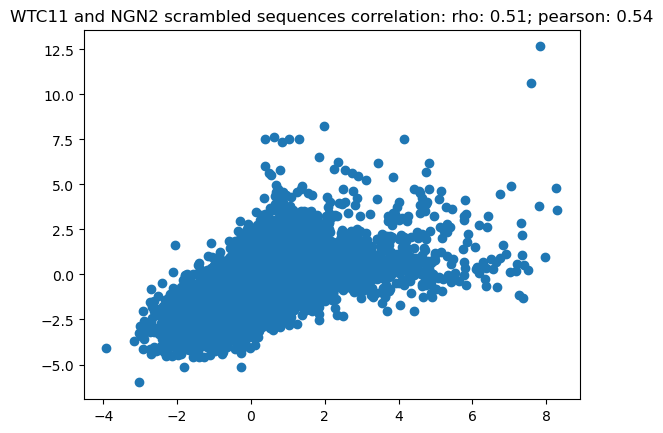

In [ ]:
wtc11_top = set(wtc11_mpra_80k_metadata_df_bcalm_no_scrambled[col_name].to_list())
ngn2_top = set(mpra_80k_metadata_df_bcalm_no_scrambled[col_name].to_list())

wtc11_ngn2_correlation_all_spear =  wtc11_mpra_80k_metadata_df_bcalm_no_scrambled.merge(mpra_80k_metadata_df_bcalm_no_scrambled.rename(columns={'bcalm_element_log_ratio_activity': 'NGN2_bcalm_element_log_ratio_activity'})[['name', 'NGN2_bcalm_element_log_ratio_activity']], on='name' , how="inner")[['bcalm_element_log_ratio_activity', 'NGN2_bcalm_element_log_ratio_activity']].corr(method="spearman").iloc[0, 1]
wtc11_ngn2_correlation_all_pearson =  wtc11_mpra_80k_metadata_df_bcalm_no_scrambled.merge(mpra_80k_metadata_df_bcalm_no_scrambled.rename(columns={'bcalm_element_log_ratio_activity': 'NGN2_bcalm_element_log_ratio_activity'})[['name', 'NGN2_bcalm_element_log_ratio_activity']], on='name' , how="inner")[['bcalm_element_log_ratio_activity', 'NGN2_bcalm_element_log_ratio_activity']].corr(method="pearson").iloc[0, 1]
combined_wtc11_ngn2 = wtc11_mpra_80k_metadata_df_bcalm_no_scrambled.merge(mpra_80k_metadata_df_bcalm_no_scrambled.rename(columns={'bcalm_element_log_ratio_activity': 'NGN2_bcalm_element_log_ratio_activity'})[['name', 'NGN2_bcalm_element_log_ratio_activity']], on='name' , how="inner").copy()

import matplotlib.pyplot as plt
plt.scatter(combined_wtc11_ngn2["NGN2_bcalm_element_log_ratio_activity"], combined_wtc11_ngn2["bcalm_element_log_ratio_activity"])
plt.title(f"WTC11 and NGN2 scrambled sequences correlation: rho: {round(wtc11_ngn2_correlation_all_spear,2)}; pearson: {round(wtc11_ngn2_correlation_all_pearson,2)}")


In [ ]:
element_metadata_with_bcalm_2025_02_bbmap_scrambled

variants_metadata_bcalm_2025_bbmap_scrambled

WTC11_variants_metadata_bcalm_2025_bbmap_scrambled

WTC11_element_metadata_with_bcalm_2025_02_bbmap_scrambled

# load wtc11 results

bcalm_wtc11_element_path = "/home/kisa/coding/80K_MPRA/element_analysis_output//WTC11_202503_80k_element_bbmap_outlier_removed_toptreat_results_scrambled_NP_MK_result_095.tsv"

bcalm_wtc11_element = pd.read_csv(bcalm_wtc11_element_path, sep="\t")

# add label
bcalm_wtc11_element['label'] = bcalm_wtc11_element['name'].apply(hf.get_label)

In [ ]:
bcalm_wtc11_element.sort_values(by="logFC", inplace=True, ascending=True)

In [ ]:
bcalm_wtc11_element

,logFC,AveExpr,t,P.Value,adj.P.Val,name,label
74,-1.802889,-1.802684,10.328532,1.699447e-09,9.506706e-07,cardiac_neuro_cava_random:ALT_SMAD2|ENSG000001...,cardiac_neuro_cava_random
57,-1.551340,-1.551742,12.932414,7.500048e-12,5.425250e-09,C_negative_neuron_NP:NGN2_iPSC_ABC_chr4_112626...,C_negative_neuron_NP
114,-1.547548,-1.546546,8.811819,1.942259e-06,7.085869e-04,cardiac_neuro_cava_random:ALT_SLC6A1|ENSG00000...,cardiac_neuro_cava_random
136,-1.376128,-1.376379,8.821316,1.007259e-05,3.084637e-03,cardiac_neuro_cava_random:REF_TNNT2|ENSG000001...,cardiac_neuro_cava_random
145,-1.375005,-1.374347,8.379713,2.569742e-05,7.347612e-03,cardiac_neuro_cava_random:ALT_ACVR1|ENSG000001...,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...
5,2.472523,2.472401,13.716041,1.033599e-39,7.227443e-36,GC_GABA_Chengyu:GABA|chr2:68908455-68908724|+|...,GC_GABA_Chengyu
2,3.173581,3.173781,17.977062,3.066197e-63,4.288077e-59,GC_GABA_Chengyu:GABA|chr12:29884985-29885254|+...,GC_GABA_Chengyu
10,3.183002,3.182318,12.542945,7.249179e-34,2.764903e-30,C_positive_neuron_NP:GW18_PFC_ABC_NGN2_iPSC_AB...,C_positive_neuron_NP
1,3.791535,3.791717,19.307143,4.183164e-71,8.775233e-67,C_positive_neuron_NP:GW18_PFC_ABC_NGN2_iPSC_AB...,C_positive_neuron_NP


In [ ]:
# load wtc11 and ngn2 bcalm results

# get the label and only the groups of chengyu

# check if the group group sizes >200

# groupby label and sort by activity

# take top 200 and bottom 200


### Investigate the Elements with activity: 
- what are the groups sizes of NGN2 significant element activity and WTC11 significant element activity

In [ ]:
# NGN2 get the elements with higher than scrambled activity
mpra_80k_metadata_df_bcalm_no_scrambled.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized'],
      dtype='object')

In [14]:
ngn2_significant_active_elements = mpra_80k_metadata_df_bcalm_no_scrambled.loc[mpra_80k_metadata_df_bcalm_no_scrambled['bcalm_element_adjusted_p_value'] < 0.1].copy()

In [16]:
ngn2_significant_active_elements['label'] = ngn2_significant_active_elements['name'].apply(hf.get_label)

In [22]:
tested_ngn2_significant_active_elements = ngn2_significant_active_elements.loc[ngn2_significant_active_elements['name'].str.contains('cardiac_neuro_cava_random')].copy()
tested_ngn2_significant_active_elements # 5162 significant sequences (including variants)
tested_ngn2_significant_active_elements.drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0] # 2635 different regions

tested_ngn2_significant_active_elements = tested_ngn2_significant_active_elements.loc[~tested_ngn2_significant_active_elements['name'].str.contains(":ALT_")]

In [23]:
tested_ngn2_significant_active_elements

,name,sequence,category,class,source,ref,chr,start,end,strand,...,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized
26153,cardiac_neuro_cava_random:REF_TRAK1|ENSG000001...,AAAGCATGAATGTGGGGGAGGGCGGGGGCGGGGACTGCTTCTCTTG...,variant,test,<NA>,GRCh38,chr3,42025667,42025937,+,...,"[78, 193, 199, 217]","[NC_000003.12:42025745:G:C, NC_000003.12:42025...","[ref, ref, ref, ref]",NaN,4.052892e-51,7.729641,True,cardiac_neuro_cava_random,7.729641,2.790917
6957,cardiac_neuro_cava_random:ZBTB20|ENSG000001817...,ACCTTTGTGTGGACACTCTGTATCCAGCTAATCTGGTGGGGATGTG...,element,test,<NA>,GRCh38,chr3,114812086,114812356,-,...,None,None,None,NaN,6.544915e-98,7.332373,True,cardiac_neuro_cava_random,7.332373,2.637603
27957,cardiac_neuro_cava_random:REF_LINC01033|ENSG00...,TCAGAATCAGAACTGCAAGAGAGCTTCACCCAGCAACTGTGGACAG...,variant,test,<NA>,GRCh38,chr5,54344722,54344992,+,...,"[76, 133]","[NC_000005.10:54344798:T:C, NC_000005.10:54344...","[ref, ref]",NaN,2.610688e-87,7.072771,True,cardiac_neuro_cava_random,7.072771,2.537418
31904,cardiac_neuro_cava_random:REF_OFD1|ENSG0000004...,TGCTCACTGCTAGCGCAGCAGTCTGAGATTGAACTGTGAGGCAGCA...,variant,test,<NA>,GRCh38,chrX,13724988,13725258,+,...,"[114, 156, 232]","[NC_000023.11:13725102:G:A, NC_000023.11:13725...","[ref, ref, ref]",NaN,5.377146e-29,6.658842,True,cardiac_neuro_cava_random,6.658842,2.377674
22381,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,GGAAAACCATGCCCTCCAGGGACTGCACTATATTTTATAGGCAGGC...,variant,test,<NA>,GRCh38,chr17,67322133,67322403,-,...,"[239, 210]","[NC_000017.11:67322163:C:T, NC_000017.11:67322...","[ref, ref]",NaN,7.934569e-155,6.412988,True,cardiac_neuro_cava_random,6.412988,2.282794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16701,cardiac_neuro_cava_random:REF_MYPN|ENSG0000013...,GCATGGAAATTCTCCCATGCTTACCGTCCAAGTGAAGACTTCCTCT...,variant,test,<NA>,GRCh38,chr10,68106708,68106978,+,...,"[140, 191]","[NC_000010.11:68106848:T:C, NC_000010.11:68106...","[ref, ref]",NaN,1.622247e-11,-4.385955,True,cardiac_neuro_cava_random,-4.385955,-1.884740
9126,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,AGCTGGAACAGATGAAGGAGAAAATGGAGAGCTCCAGCAGCGATGA...,element,test,<NA>,GRCh38,chr9,107003336,107003606,+,...,None,None,None,NaN,5.699541e-11,-4.454358,True,cardiac_neuro_cava_random,-4.454358,-1.911138
6528,cardiac_neuro_cava_random:TDGF1|ENSG0000024118...,AACACTGATGCTGCAGTCAGCAGACACCTCACCTGCATTGCTGTGT...,element,test,<NA>,GRCh38,chr3,46584816,46585086,+,...,None,None,None,NaN,2.407800e-11,-4.797462,True,cardiac_neuro_cava_random,-4.797462,-2.043549
18618,cardiac_neuro_cava_random:REF_CUX2|ENSG0000011...,AGCCTGGGCGACAGAGCAAGACTCTCTCTCAAAAACAAAACAAAAC...,variant,test,<NA>,GRCh38,chr12,111263594,111263864,+,...,[138],[NC_000012.12:111263732:G:A],[ref],NaN,8.366452e-14,-4.883640,True,cardiac_neuro_cava_random,-4.883640,-2.076807


In [17]:
ngn2_significant_active_elements['label'].value_counts()

label
cardiac_neuro_cava_random    5162
MK                            750
C_positive_neuron_MK           79
C_negative_neuron_NP           78
C_positive_neuron_NP           67
C_positive_heart_AB            52
C_negative_neuron_MK           50
GC_Cort_Chengyu                41
GC_Selvarajan                  34
C_negative_heart_MK            27
C_positive_neuron_CD           24
GC_Mendelian_variants          19
C_positive_heart_MK            18
GC_Vista                       12
C_positive_heart_CAD            6
C_SLEA                          6
GC_Mohlke                       3
GC_Glut_Chengyu                 3
GC_GABA_Chengyu                 2
GC_Liang                        1
Name: count, dtype: int64

In [ ]:
wtc11_mpra_80k_metadata_df_bcalm_no_scrambled